In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[8],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

In [4]:
#%env PYTHONWARNINGS=error

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=4,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='ss',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    #rank_grid=[1],
    verbose=True,
    extra_train_info=False,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/4...

Trying rank (1, 1)	score: 0.9372
Trying rank (2, 2)	score: 0.9336
Trying rank (4, 4)	score: 0.9220
Trying rank (8, 8)	score: 0.9153
Trying rank (8, 16)	score: 0.9322
Trying rank (8, 32)	score: 0.9238
Trying rank (8, 48)	score: 0.8788

Selected rank (1, 1) with score 0.9372
New ranks: [(1, 1)]


Model selection block 2/4...

Trying rank (1, 1)	score: 0.9448
Trying rank (2, 2)	score: 0.9462
Trying rank (4, 4)	score: 0.9453
Trying rank (8, 8)	score: 0.9442
Trying rank (8, 16)	score: 0.9435
Trying rank (8, 32)	score: 0.9454
Trying rank (8, 48)	score: 0.9386

Selected rank (2, 2) with score 0.9462
New ranks: [(1, 1), (2, 2)]


Model selection block 3/4...

Trying rank (1, 1)	score: 0.9432
Trying rank (2, 2)	score: 0.9496
Trying rank (4, 4)	score: 0.9484
Trying rank (8, 8)	score: 0.9466
Trying rank (8, 16)	score: 0.9466
Trying rank (8, 32)	score: 0.9470
Trying rank (8, 48)	score: 0.9470

Selected rank (2, 2) with score 0.9496
New ranks: [(1, 1), (2, 2), (2, 2)]


GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF()),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function CupyBackend.to_numpy at 0x7f32821c88b0>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (4, 4), 'shrinkage': 'lw',
                         'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                         'tol': 1e-08, 'verbose': False},
            max_blocks=4, n_jobs=1, verbose=True)

In [6]:
bttda.model_select_info_

fold  train_score  val_score  n_features  test_score
block rank                                                         
0     (1, 1)      0     0.945176   0.940133           1    0.936882
      (1, 1)      1     0.949913   0.919077           1    0.939580
      (1, 1)      2     0.944586   0.941516           1    0.940697
      (1, 1)      3     0.941077   0.959767           1    0.938823
      (1, 1)      4     0.948364   0.925383           1    0.941492
...             ...          ...        ...         ...         ...
3     (8, 48)     0     0.961142   0.945438         393    0.950030
      (8, 48)     1     0.962995   0.938680         393    0.955464
      (8, 48)     2     0.958288   0.955579         393    0.952368
      (8, 48)     3     0.958026   0.956703         393    0.949301
      (8, 48)     4     0.959192   0.950152         393    0.952728

[140 rows x 5 columns]

In [7]:
bttda.model_select_info_best_

fold  train_score  val_score  n_features  test_score
block rank                                                        
0     (1, 1)     0     0.945176   0.940133           1    0.936882
      (1, 1)     1     0.949913   0.919077           1    0.939580
      (1, 1)     2     0.944586   0.941516           1    0.940697
      (1, 1)     3     0.941077   0.959767           1    0.938823
      (1, 1)     4     0.948364   0.925383           1    0.941492
1     (2, 2)     0     0.957537   0.936849           5    0.943518
      (2, 2)     1     0.959110   0.935079           5    0.950267
      (2, 2)     2     0.954291   0.953705           5    0.949245
      (2, 2)     3     0.952980   0.961380           5    0.947683
      (2, 2)     4     0.957432   0.943976           5    0.949339
2     (2, 2)     0     0.960639   0.944694           9    0.947115
      (2, 2)     1     0.962985   0.937752           9    0.954801
      (2, 2)     2     0.957872   0.957420           9    0.951772
      (2, 2)     3     0.957500   0.958642           9    0.949178
      (2, 2)     4     0.959527   0.949256           9    0.950712
3     (4, 4)     0     0.962815   0.947266          25    0.950333
      (4, 4)     1     0.964503   0.936562          25    0.958568
      (4, 4)     2     0.961058   0.952564          25    0.954214
      (4, 4)     3     0.958887   0.962798          25    0.954072
      (4, 4)     4     0.961878   0.948914          25    0.951365

In [8]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['val_score'].aggregate('mean')

block  rank  
0      (1, 1)    0.937175
1      (2, 2)    0.946198
2      (2, 2)    0.949553
3      (4, 4)    0.949621
Name: val_score, dtype: float64

In [9]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['test_score'].aggregate('mean')

block  rank  
0      (1, 1)    0.939495
1      (2, 2)    0.948010
2      (2, 2)    0.950716
3      (4, 4)    0.953711
Name: test_score, dtype: float64

block  rank  
0      (1, 1)    0.807051
1      (8, 8)    0.820216
2      (8, 8)    0.825298
3      (8, 8)    0.828784
4      (4, 4)    0.829647
5      (8, 8)    0.832404
6      (8, 8)    0.834165
7      (4, 4)    0.835178
Name: val_score, dtype: float64

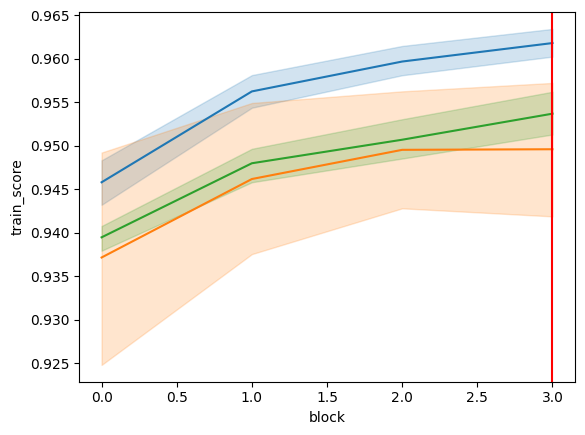

In [10]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.style.use('default')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='train_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='val_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='test_score')
plt.axvline(bttda.n_blocks_-1, color='red')

<Axes: xlabel='block', ylabel='n_features'>

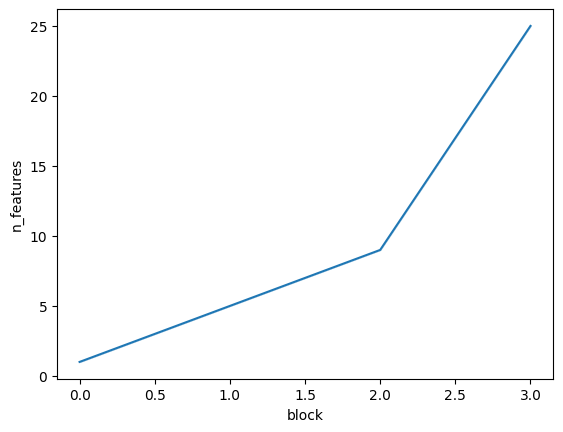

In [11]:
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='n_features')


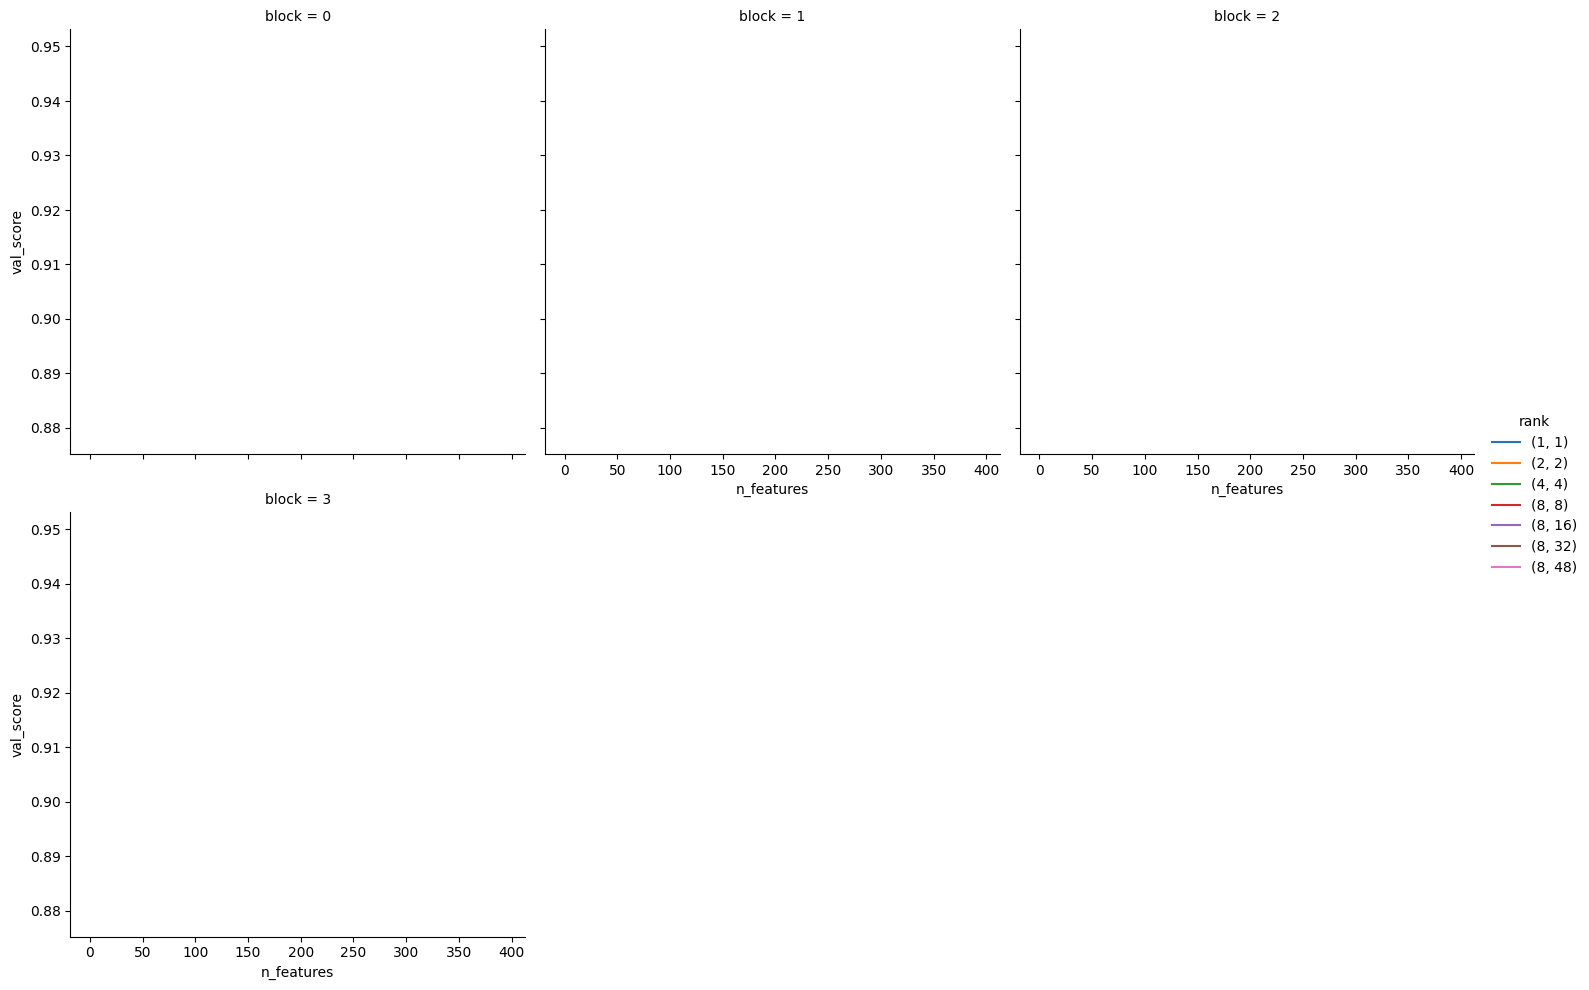

In [12]:
sns.relplot(
    data=bttda.model_select_info_.reset_index(),
    x='n_features',
    y='val_score',
    hue='rank',
    palette='tab10',
    col='block',
    kind='line',
    col_wrap=3,
    errorbar=None,
)
#plt.xscale('log')